In [1]:
%pylab inline
import torch 
import torch.nn as nn 
import torchtext 
import os
from glob import glob 
from unidecode import unidecode
import string
from tqdm import trange
import time 

device = torch.device("cpu" if torch.cuda.is_available() else "cuda")

Populating the interactive namespace from numpy and matplotlib


In [2]:
# Refer: https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html
# Task: Classify Names with proper category 

# Load Data 
path = "datasets/char-rnn-data/names/*.txt"
findfiles = lambda path: glob(path)
data_files = findfiles(path)

def readlines(data_files):
    lines = open(data_files).read().strip().split('\n')
    return [unidecode(name) for name in lines]

category_lines = {}
all_categories = []
for file in findfiles(path):
    category = os.path.basename(file).replace(".txt", "")
    all_categories.append(category)
    lines = readlines(file)
    category_lines[category] = lines
n_categories = len(all_categories)

In [3]:
# Turning Names to Tensor 
data_chars = string.ascii_letters + " .,;'"
n_chars = len(data_chars)
char_to_index = lambda c: data_chars.find(c)

def char_to_tensor(char):
    tensor = torch.zeros(1, n_chars)
    tensor[0][char_to_index(char)] = 1
    return tensor.to(device)

def line_to_tensor(line):
    tensor = torch.zeros(len(line), 1, n_chars)
    for i, char in enumerate(line):
        tensor[i][0][char_to_index(char)] = 1 
    return tensor.to(device)



In [4]:
# RNN
class RNN(nn.Module):
    def __init__(self, in_size, h_size, out_size):
        super(RNN, self).__init__()
        self.h_size = h_size

        self.i2h = nn.Linear(in_size + h_size, h_size)
        self.i2o = nn.Linear(in_size + h_size, out_size)
        self.softmax = nn.LogSoftmax(dim=1)
    
    def forward(self, x, h):
        combined = torch.cat((x, h), 1)
        h = self.i2h(combined)
        out = self.i2h(combined)
        out = self.i2o(combined)
        out = self.softmax(out)
        return out, h 
    
    def init_h(self):
        return torch.zeros(1, self.h_size).to(device)
    
n_h = 128 
rnn = RNN(n_chars, n_h, n_categories).to(device)



In [5]:
def category_to_out(out):
    top_n, top_i = out.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i 

# Get Training Example 
def random_example():
    category = np.random.choice(all_categories)
    line = np.random.choice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long).to(device)
    l2t = line_to_tensor(line)
    return category, line, category_tensor, l2t
for i in range(10):
    category, line, category_tensor, l2t = random_example()
    print(f"category = {category}, line = {line}, {category_tensor}") 

category = Italian, line = Aiolfi, tensor([9])
category = German, line = Hummel, tensor([2])
category = Portuguese, line = Coelho, tensor([3])
category = Arabic, line = Kattan, tensor([5])
category = Scottish, line = King, tensor([0])
category = Portuguese, line = Rosario, tensor([3])
category = Vietnamese, line = Banh, tensor([6])
category = Vietnamese, line = Do, tensor([6])
category = Italian, line = Amalberti, tensor([9])
category = Japanese, line = Okuma, tensor([13])


In [6]:
def train(category_tensor, line_tensor):
    loss_function = nn.NLLLoss()
    opt = torch.optim.SGD(rnn.parameters(), lr=0.005)
    h = rnn.init_h()
    # Forward Pass 
    for i in range(line_tensor.shape[0]):
        out, h = rnn(line_tensor[i], h)
    loss = loss_function(out, category_tensor)

    # Update weights 
    opt.zero_grad()
    loss.backward()
    opt.step()
    return out, loss.item()

100%|██████████| 100000/100000 [01:51<00:00, 893.87it/s]


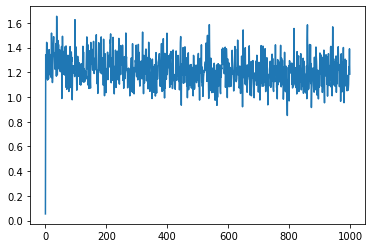

In [13]:
# Training Loop 
epochs = 100000
losses = []
plot_steps = epochs / 1000
print_steps = epochs / 5 
cur_loss = 0  

for t in trange(epochs):
    category, line, category_tensor, line_tensor = random_example()
    out, loss = train(category_tensor, line_tensor)
    cur_loss += loss
    

    if t % print_steps == 0:
        guess, _ = category_to_out(out)
        correct = "YES" if guess == category else f"NO ({category})"
        print(f" loss = {loss:.2f}, {line} / {guess} {correct}")
    
    if t % plot_steps == 0:
        losses.append(cur_loss / plot_steps)
        cur_loss = 0 
plt.figure()
plt.plot(losses)

In [23]:
p

TypeError: 'str' object is not callable